In [2]:
import pandas as pd 
import matplotlib.pyplot as plt

df = pd.read_csv("netflix.csv")

<h2>Content Strategy</h2>

<h3>1. What is the ratio of Movies vs TV Shows on Netflix?</h3>

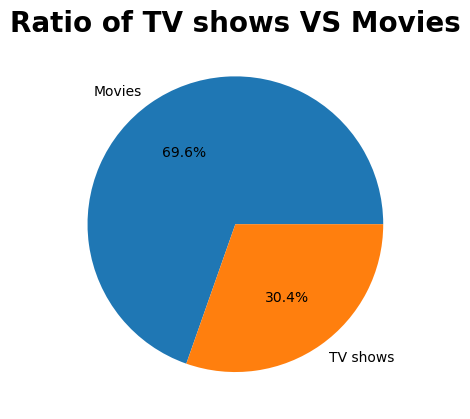

In [5]:
ratio_counts = df['type'].value_counts()

labels = ['Movies', 'TV shows']

plt.figure()
plt.pie(ratio_counts.sort_index(), labels=labels, autopct='%1.1f%%',)

plt.title("Ratio of TV shows VS Movies", fontweight='bold', fontsize=20)

plt.show()

<h4>Insights</h4>

- According to this ratio movies are more than tv shows.
- This graph shows netflix promotes movies more than tv shows.
- Peoples are preffering to watch movies more so more movies are promoted on platform.
- Peoples are not interested to watch shows on this platform.

<h3>2. Which genres are most popular on Netflix globally?</h3>

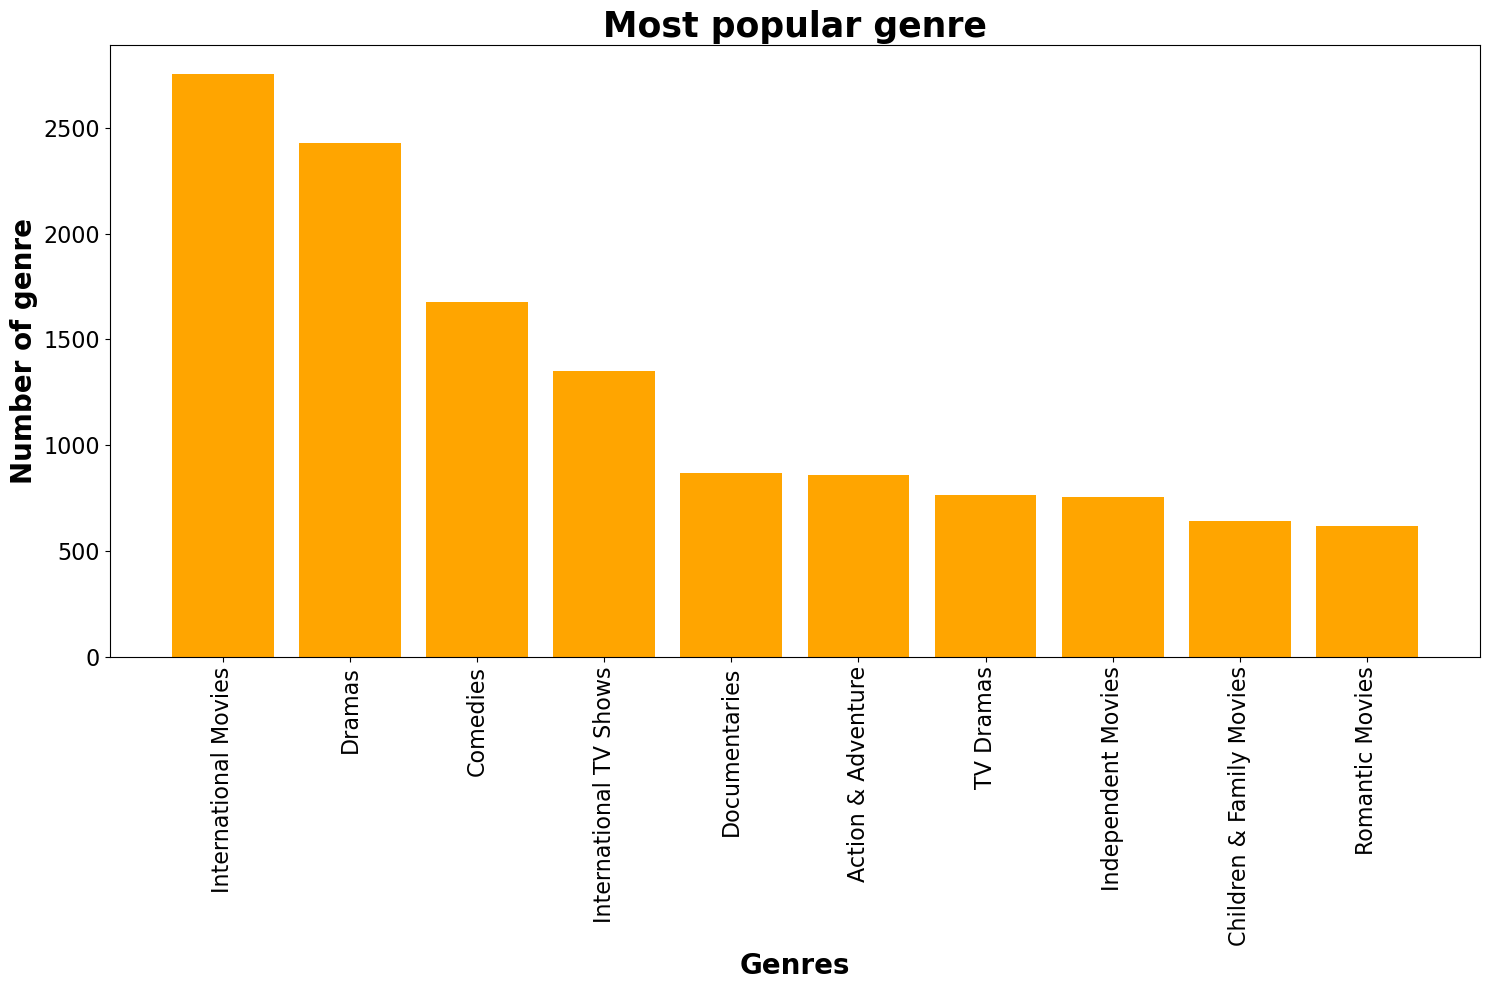

In [32]:
df['listed_in'] = df['listed_in'].str.split(', ')
df = df.explode('listed_in')

genres_count = df['listed_in'].value_counts().head(10)

plt.figure(figsize=(15,10))
plt.bar(genres_count.index, genres_count.values, color='orange')

plt.xlabel("Genres", fontweight='bold', fontsize=20)
plt.ylabel("Number of genre", fontweight='bold', fontsize=20)
plt.title("Most popular genre", fontweight='bold', fontsize=25)

plt.xticks(rotation=90, fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()



<h4>Insights</h4>

- Most loved genre is International movies more than 2500 movies are listed in it.
- Dramas, Comedies and Internatinal TV shows are also popular on netflix.
- Last six genres are not popular as first four genres means peoples like them less.
- According to this graph making  a movie or tv show based on first four genres is being profitable. 

<h3>3. Which years saw the highest release of content on Netflix?</h3>

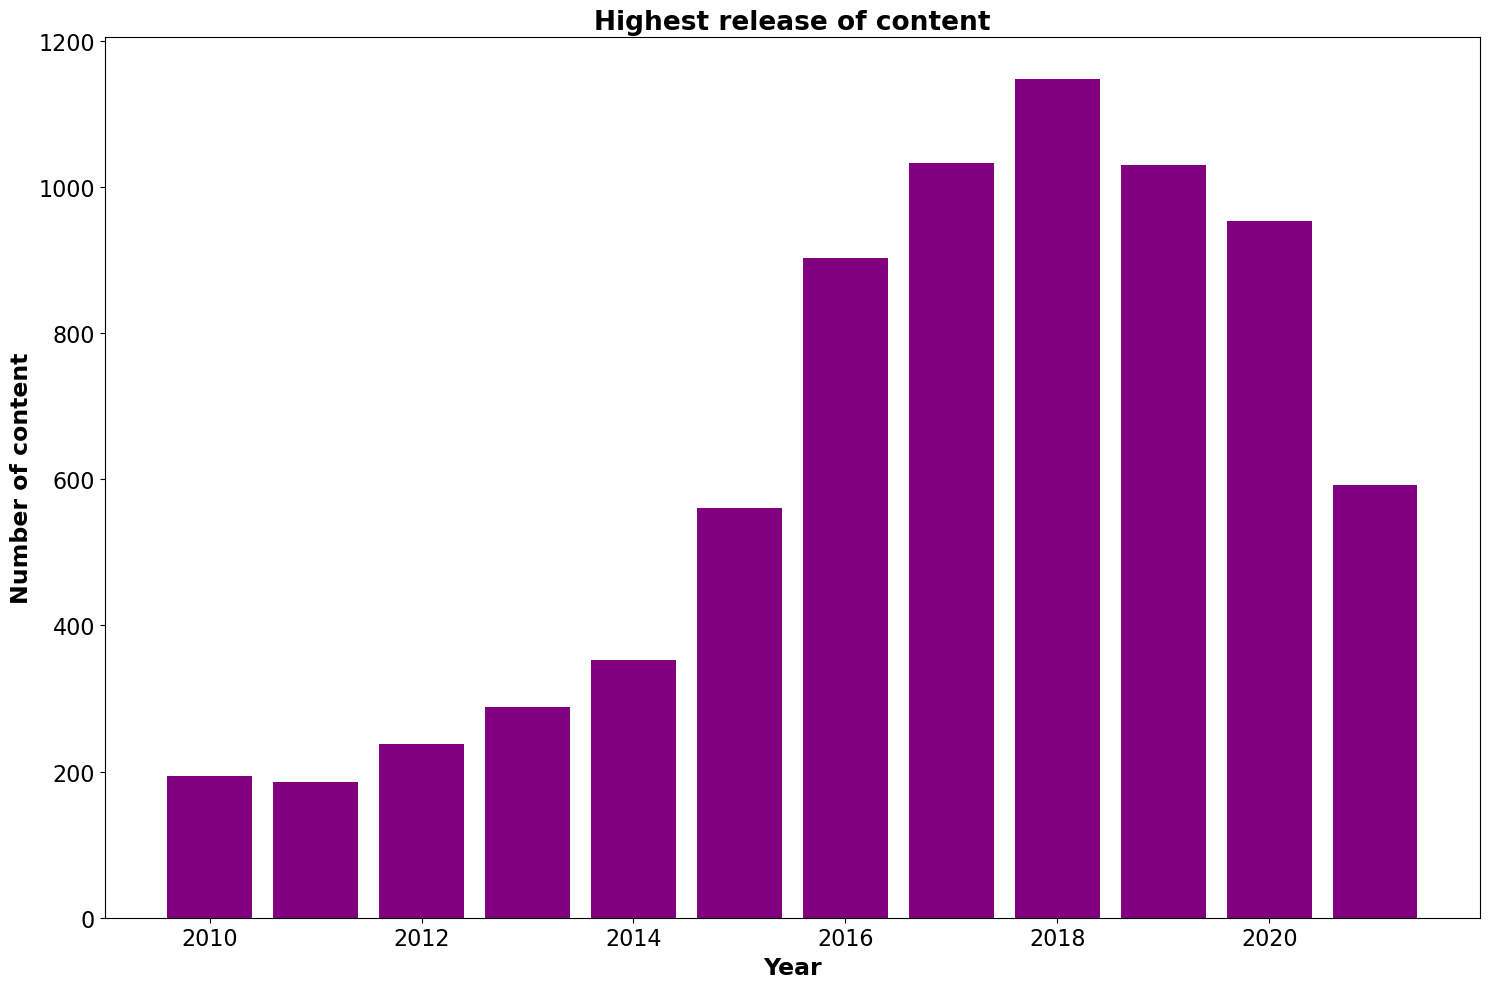

In [7]:
year_count = df['release_year'].value_counts().head(12)

plt.figure(figsize=(15,10))
plt.bar(year_count.index, year_count.values, color='purple')

plt.xlabel("Year", fontweight='bold', fontsize=17)
plt.ylabel("Number of content", fontweight='bold', fontsize=17)
plt.title("Highest release of content", fontweight='bold', fontsize=19)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()

<h4>Insights</h4>

- The graph is continiously increasing till year 2018 and then it is decreasing.
- Highest no. of content is released in year 2018. In that year more than 1100 contents are released.
- After 2018 the no. of content are decreasing means peoples interest in online movies and tv sows are going down.
- In year 2017 and 2019 same no. of contents are released.

<h3>4. Which countries produce the most Netflix content?</h3>

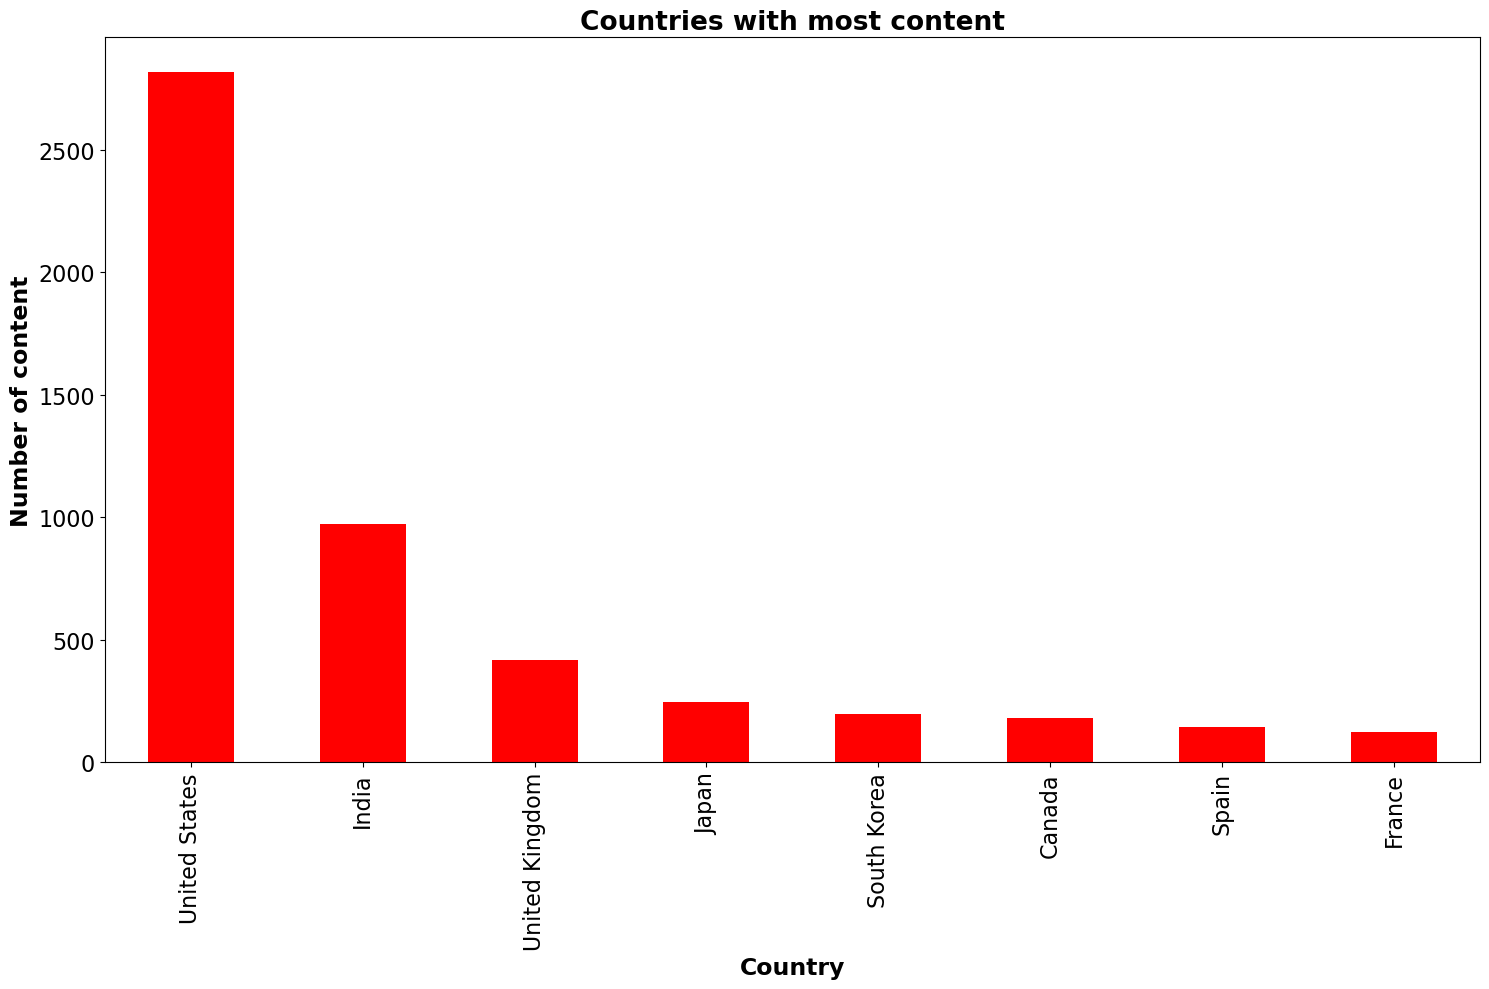

In [8]:
country_count = df['country'].value_counts().head(8)

country_count.plot(kind='bar', color='red', figsize=(15,10))

plt.xlabel("Country", fontweight='bold', fontsize=17)
plt.ylabel("Number of content", fontweight='bold', fontsize=17)
plt.title("Countries with most content", fontweight='bold', fontsize=19)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()

<h4>Insights</h4>

- United States has released more than 2500 contents which is much higher than any other countries.
- India is on second no. on producing almost 1000 netflix content  more than double of UK.
- Last five countries has produced very less content compare to first three.
- Netflix is promoting more US content as compare to other countries.

<h3>5. How has the trend of adding new content evolved year by year?</h3>

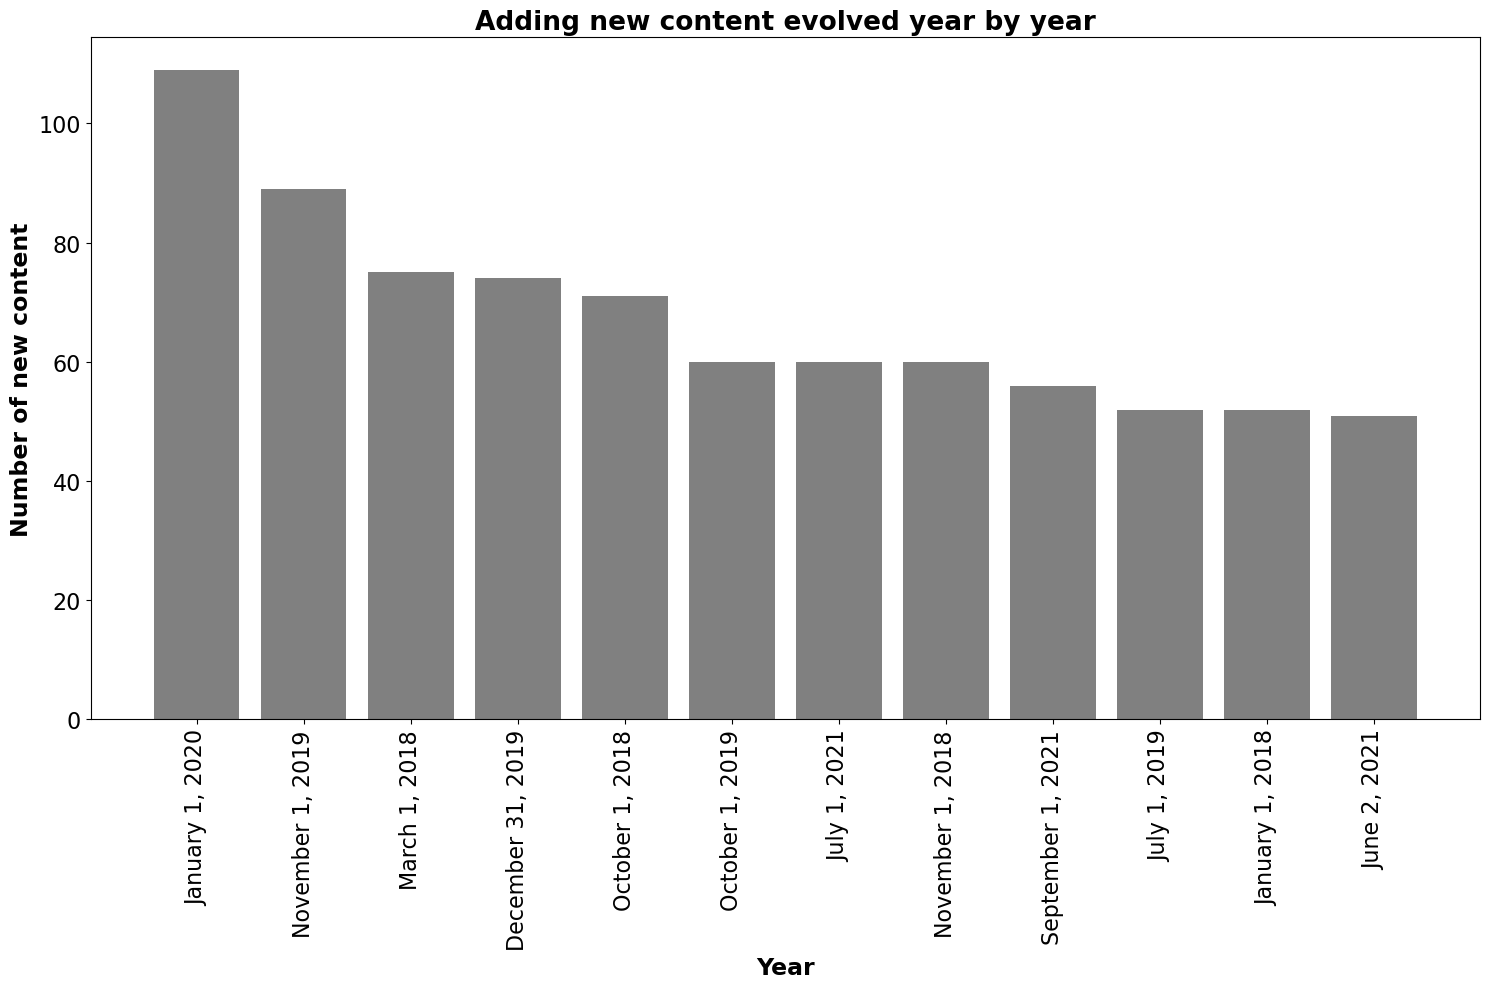

In [9]:
adding_year_count = df['date_added'].value_counts().head(12)

plt.figure(figsize=(15,10))
plt.bar(adding_year_count.index, adding_year_count.values, color='grey')

plt.xlabel("Year", fontweight='bold', fontsize=17)
plt.ylabel("Number of new content", fontweight='bold', fontsize=17)
plt.title("Adding new content evolved year by year", fontweight='bold', fontsize=19)

plt.xticks(fontsize=16, rotation=90)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()

<h4>Insights</h4>

- Content addition increased over time.
- Peak years show aggressive expansion.
- Recent years show slower growth.
- Netflix expanded rapidly in mid-years.
- Content addition trend is not constant.

<h3>User Demographics & Targeting</h3>

<h3>6. Which ratings (e.g., TV-MA, PG, etc.) are most frequent on Netflix?</h3>

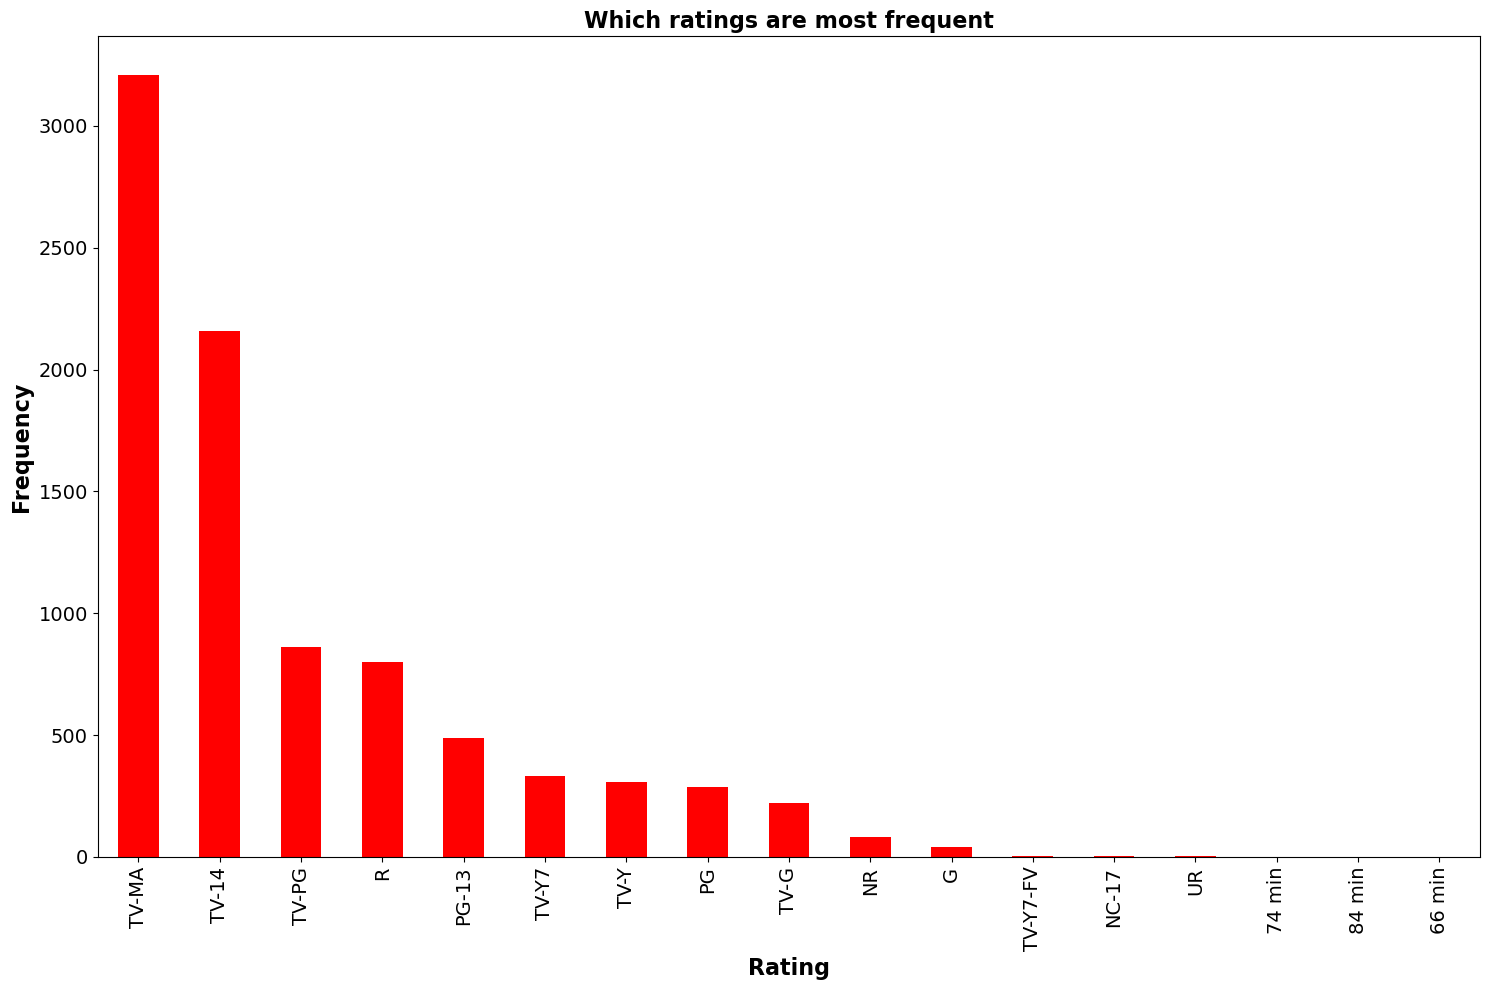

In [10]:
rating_count = df['rating'].value_counts()

rating_count.plot(kind='bar', color='red', figsize=(15,10))

plt.xlabel("Rating", fontweight='bold', fontsize=16)
plt.ylabel("Frequency", fontweight='bold', fontsize=16)
plt.title("Which ratings are most frequent", fontweight='bold', fontsize=16)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.tight_layout()
plt.show()
                  
                  

<h4>Insights</h4>

- TV-MA is the most common rating.
- Mature content dominates the platform.
- Family-friendly content is less frequent.
- Netflix targets adult audience more.
- Rating distribution is skewed towards higher age groups.

<h3>7. Do some countries tend to produce more mature content (TV-MA)?</h3>

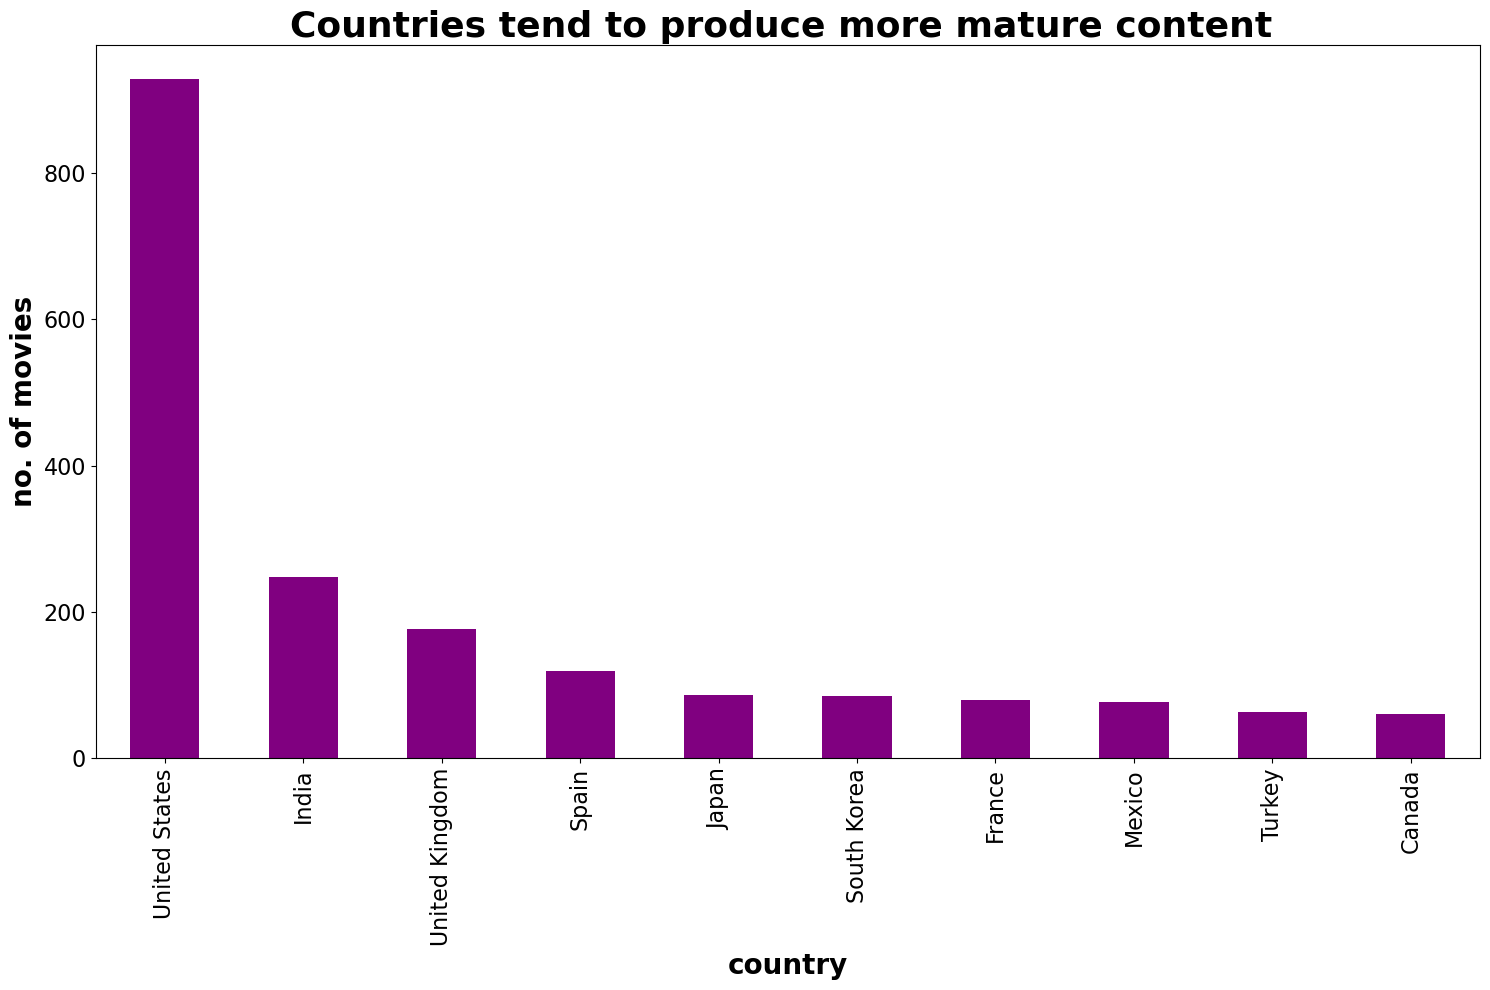

In [11]:
mature_rating = ['TV-MA']

mature_df = df[df['rating'].isin(mature_rating)]

result = mature_df.groupby('country')['rating'].count().sort_values(ascending=False).head(10)

result.plot(kind='bar', color='purple', figsize=(15,10))

plt.xlabel("country", fontweight='bold', fontsize=20)
plt.ylabel("no. of movies", fontweight='bold', fontsize=20)
plt.title("Countries tend to produce more mature content ", fontweight='bold', fontsize=26)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()

<h4>Insights</h4>

- USA produces most mature (TV-MA) content.
- Mature content is concentrated in few countries.
- India also contributes significantly.
- Mature content is globally distributed but uneven.
- Top countries dominate adult content production.

<h3>8. Which genres are more associated with TV Shows vs Movies?</h3>

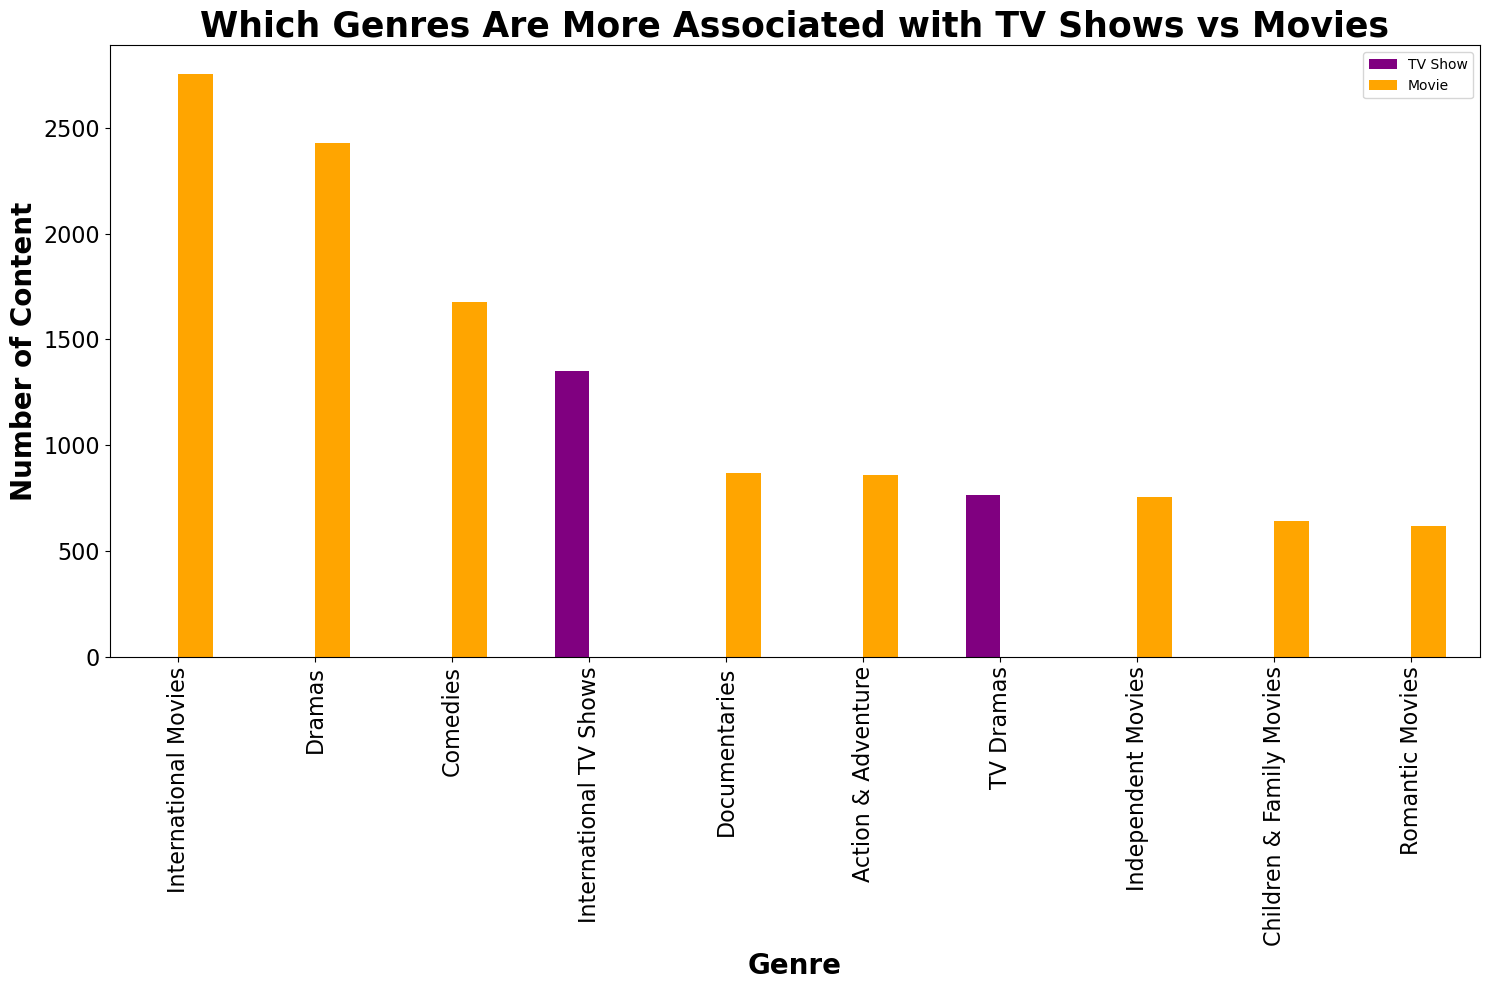

In [12]:
df['listed_in'] = df['listed_in'].str.split(', ')
df = df.explode('listed_in')

genre_counts = df.groupby(['listed_in','type']).size().unstack(fill_value=0)

genre_counts['Total'] = genre_counts.sum(axis=1)
genre_counts = genre_counts.sort_values('Total', ascending=False).head(10)

genre_counts[['TV Show','Movie']].plot(
    kind='bar',
    figsize=(15,10),
    color=['purple','orange']
)

plt.xlabel("Genre", fontweight='bold', fontsize=20)
plt.ylabel("Number of Content", fontweight='bold', fontsize=20)
plt.title("Which Genres Are More Associated with TV Shows vs Movies", fontweight='bold', fontsize=25)

plt.xticks(rotation=90, fontsize=16)
plt.yticks(fontsize=16)
plt.legend()
plt.tight_layout()
plt.show()

<h4>Insights</h4>

- Some genres are dominated by movies.
- Others are more common in TV Shows.
- Movies have higher overall counts.
- Genre preference varies by content type.
- Certain genres are exclusive to one format.

<h3>9. Which genres dominate the U.S. vs other countries?</h3>

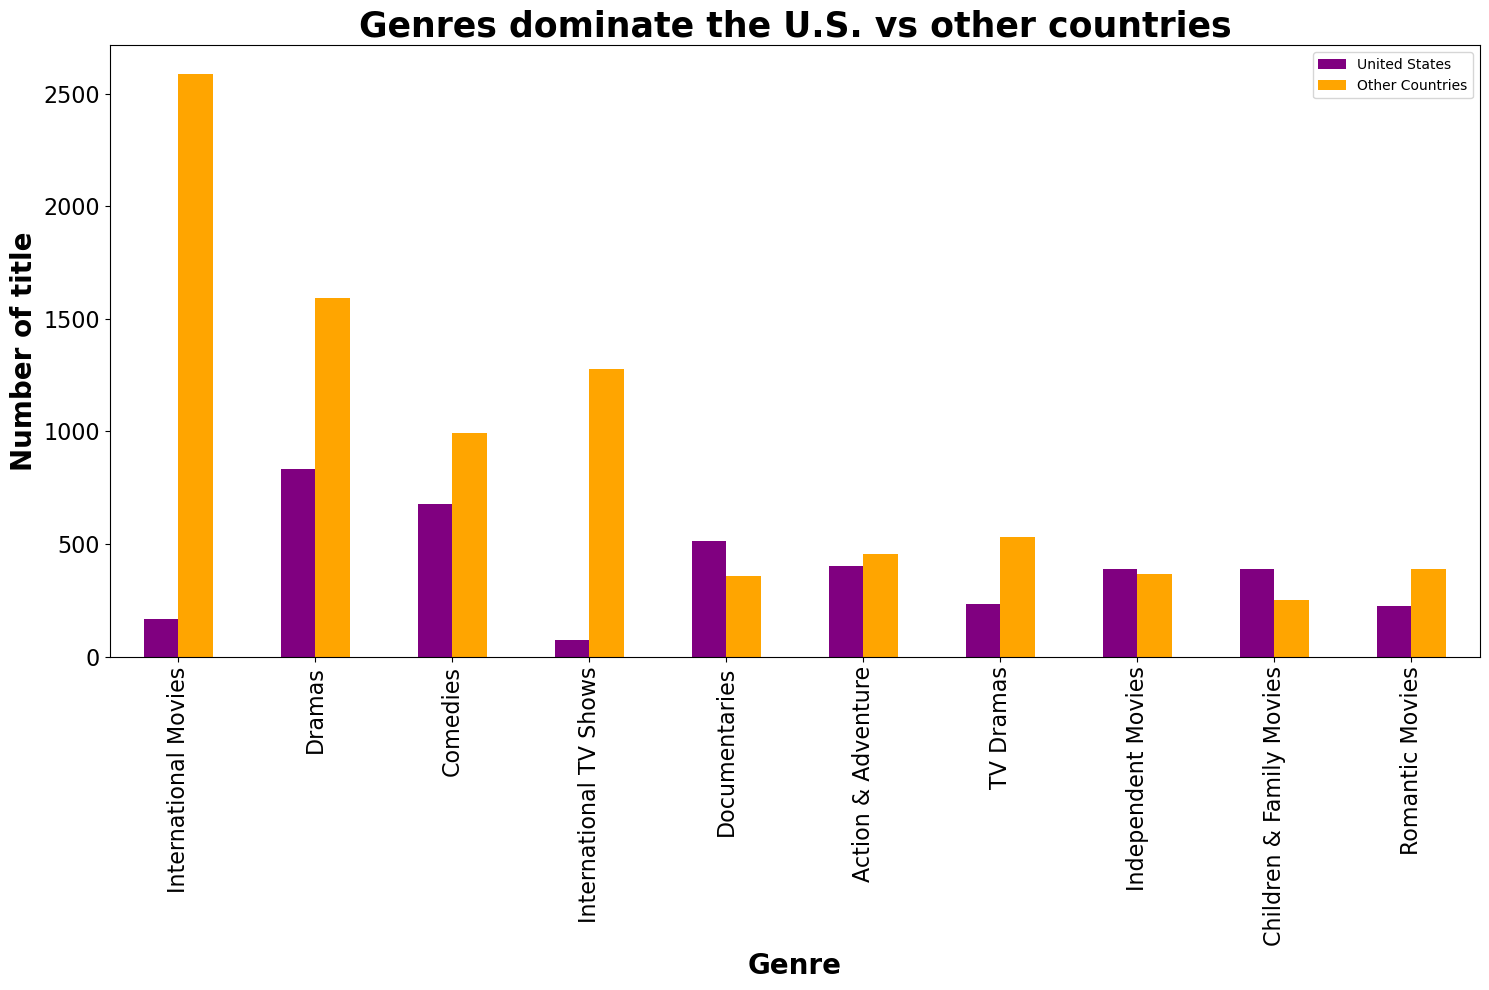

In [15]:
df['listed_in'] = df['listed_in'].str.split(', ')
df = df.explode('listed_in')

df['region'] = df['country'].apply(lambda x: 'United States' if isinstance(x,str) and 'United States' in x else 'Other Countries')

genre_counts = df.groupby(['listed_in', 'region']).size().unstack(fill_value=0)

genre_counts['Total'] = genre_counts.sum(axis=1)
genre_counts = genre_counts.sort_values('Total', ascending=False).head(10)

genre_counts[['United States','Other Countries']].plot(
    kind='bar',
    figsize=(15,10),
    color=['purple','orange']
)

plt.xlabel("Genre", fontweight='bold', fontsize=20)
plt.ylabel("Number of title", fontweight='bold', fontsize=20)
plt.title("Genres dominate the U.S. vs other countries", fontweight='bold', fontsize=25)

plt.xticks(rotation=90, fontsize=16)
plt.yticks(fontsize=16)
plt.legend()
plt.tight_layout()
plt.show()

<h4>Insights</h4>

- U.S. dominates most genres.
- Other countries contribute less but diverse content.
- Genre distribution differs by region.
- International content is strong outside U.S.
- U.S. content is more mainstream.

<h3>10.What genres are most popular in the last 3 years?</h3>

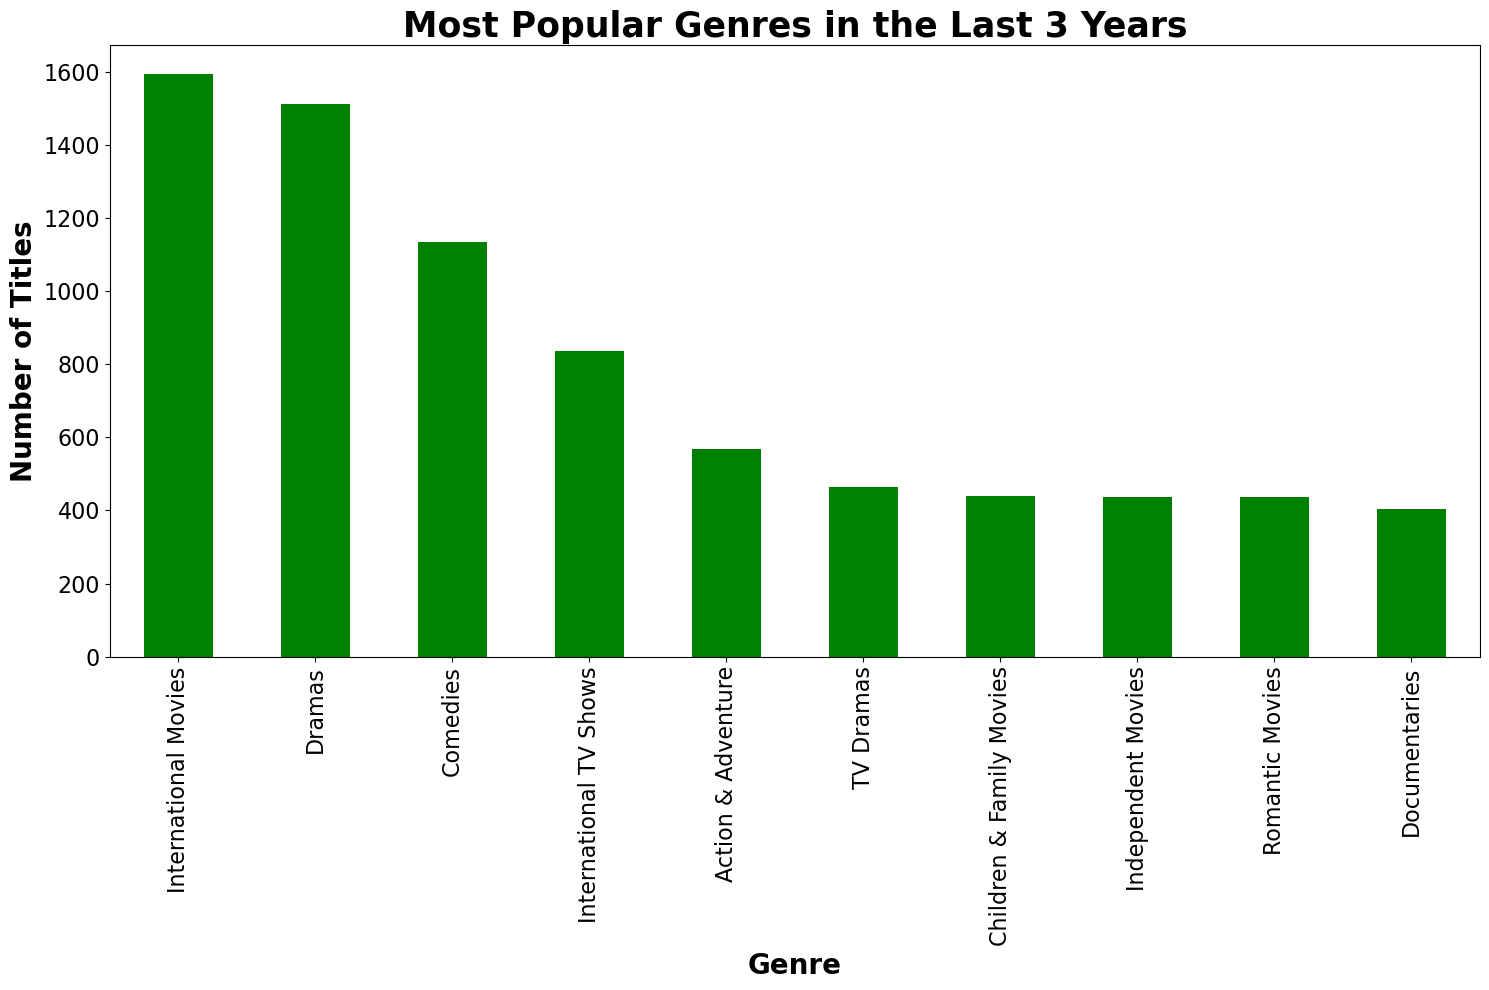

In [28]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

recent_df = df[df['date_added'].dt.year >= df['date_added'].dt.year.max() - 2]

recent_df.loc[:, 'listed_in'] = recent_df['listed_in'].str.split(', ')
recent_df = recent_df.explode('listed_in')

genre_counts = recent_df['listed_in'].value_counts().head(10)

genre_counts.plot(kind='bar', figsize=(15,10), color='green')

plt.xlabel("Genre", fontweight='bold', fontsize=20)
plt.ylabel("Number of Titles", fontweight='bold', fontsize=20)
plt.title("Most Popular Genres in the Last 3 Years", fontweight='bold', fontsize=25)

plt.xticks(rotation=90, fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()

<h4>Insights</h4>

- Recent trends show changing genre preferences.
- Some genres are growing rapidly.
- New content focuses on trending categories.
- Audience taste is evolving over time.
- Recent top genres differ from overall trends.

<h2>Talent Acquisition & Partnerships</h2>

<h3>11. Who are the top 10 directors with the most Netflix content?</h3>

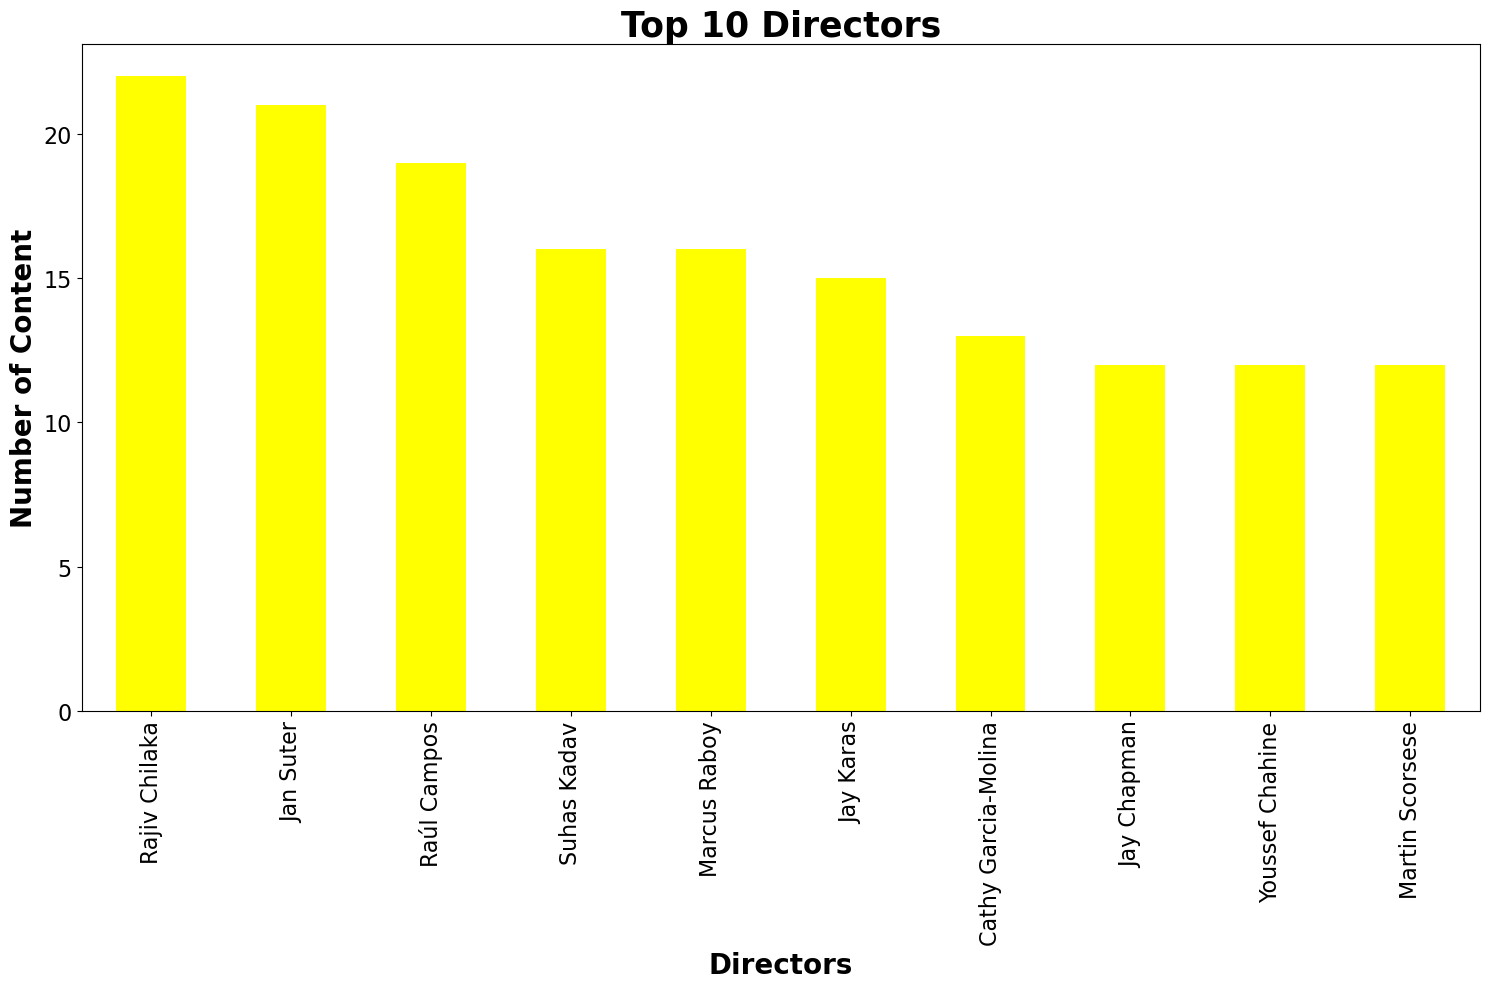

In [12]:
df.columns = df.columns.str.strip()

df = df.dropna(subset=['director'])

df['director'] = df['director'].str.split(',')
df = df.explode('director')

df['director'] = df['director'].str.strip()

directors_count = df['director'].value_counts().head(10)

directors_count.plot(kind='bar', figsize=(15,10), color='yellow')

plt.xlabel('Directors', fontweight='bold', fontsize=20)
plt.ylabel("Number of Content", fontweight='bold', fontsize=20)
plt.title("Top 10 Directors", fontweight='bold', fontsize=25)

plt.xticks(rotation=90, fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()
plt.show()

<H4>Insights</H4>

- Few directors dominate Netflix content.
- Top directors have significantly higher counts.
- Long-tail distribution for other directors.
- Frequent collaboration with certain directors.
- Director popularity impacts content volume.

<h3>12.Which actors appear most frequently in Netflix shows?</h3>

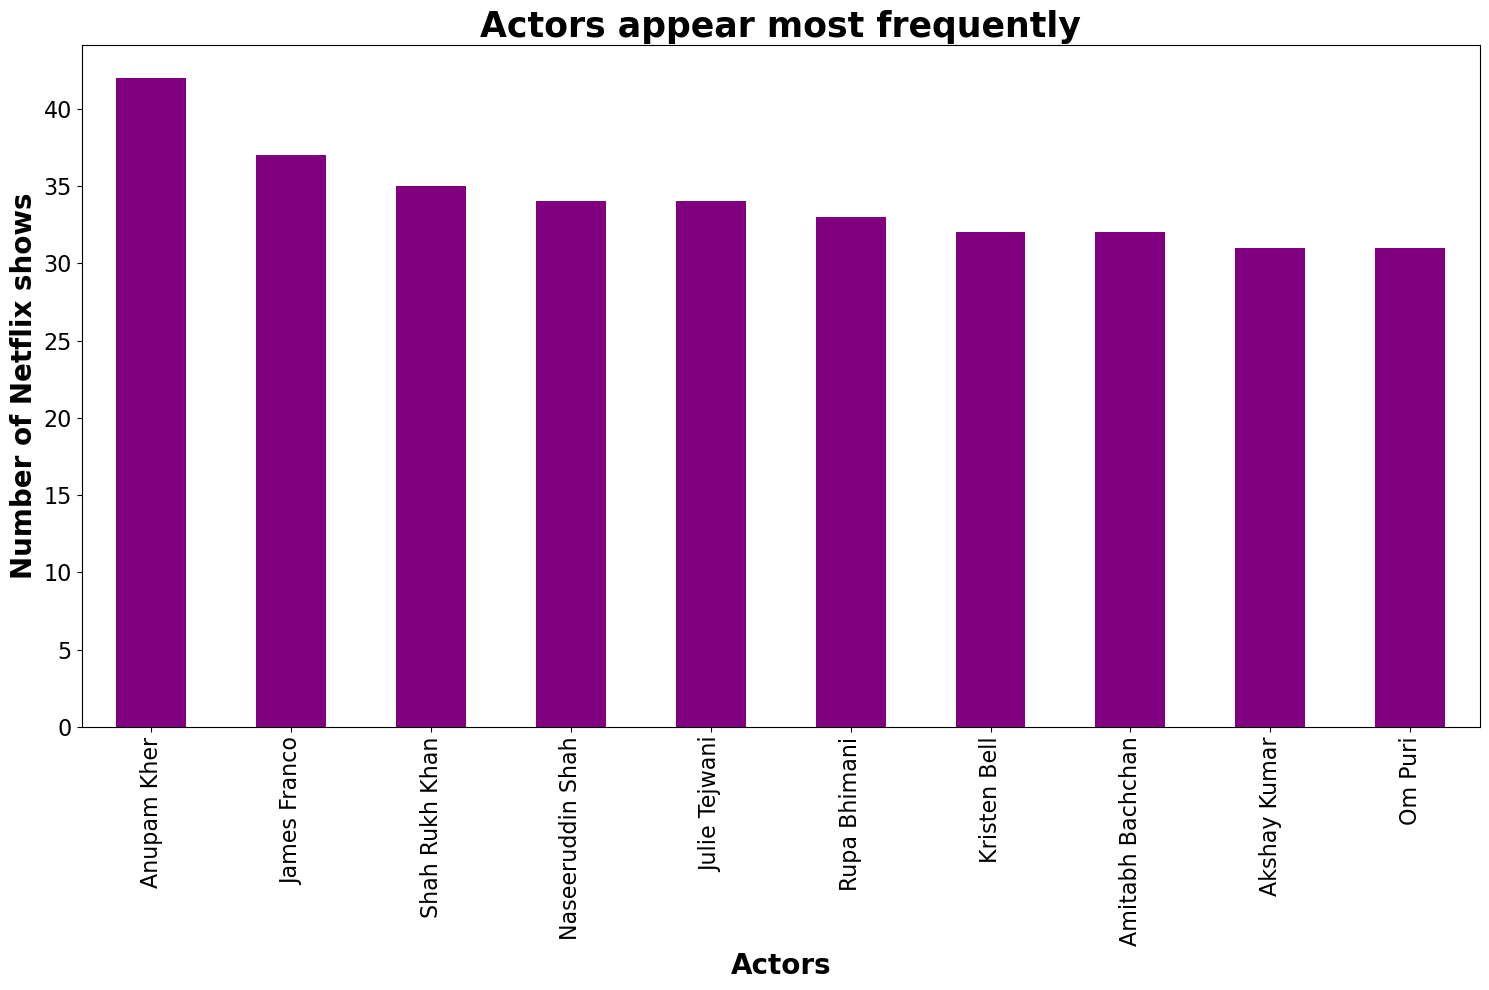

In [14]:
df.columns = df.columns.str.strip()

df = df.dropna(subset=['cast'])

df['cast'] = df['cast'].str.split(', ')
df = df.explode('cast')

df['cast'] = df['cast'].str.strip()

cast_count = df['cast'].value_counts().head(10)

cast_count.plot(kind='bar', figsize=(15,10), color='purple')

plt.xlabel('Actors', fontweight='bold', fontsize=20)
plt.ylabel("Number of Netflix shows", fontweight='bold', fontsize=20)
plt.title("Actors appear most frequently", fontweight='bold', fontsize=25)

plt.xticks(rotation=90, fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()
plt.show()

<h4>Insights</h4>

- Some actors appear very frequently.
- Majority actors have low appearances.
- Repeated casting is common.
- Popular actors drive content visibility.
- Actor distribution is uneven.

<h3>13.Which director-genre pairs are most frequent?</h3>

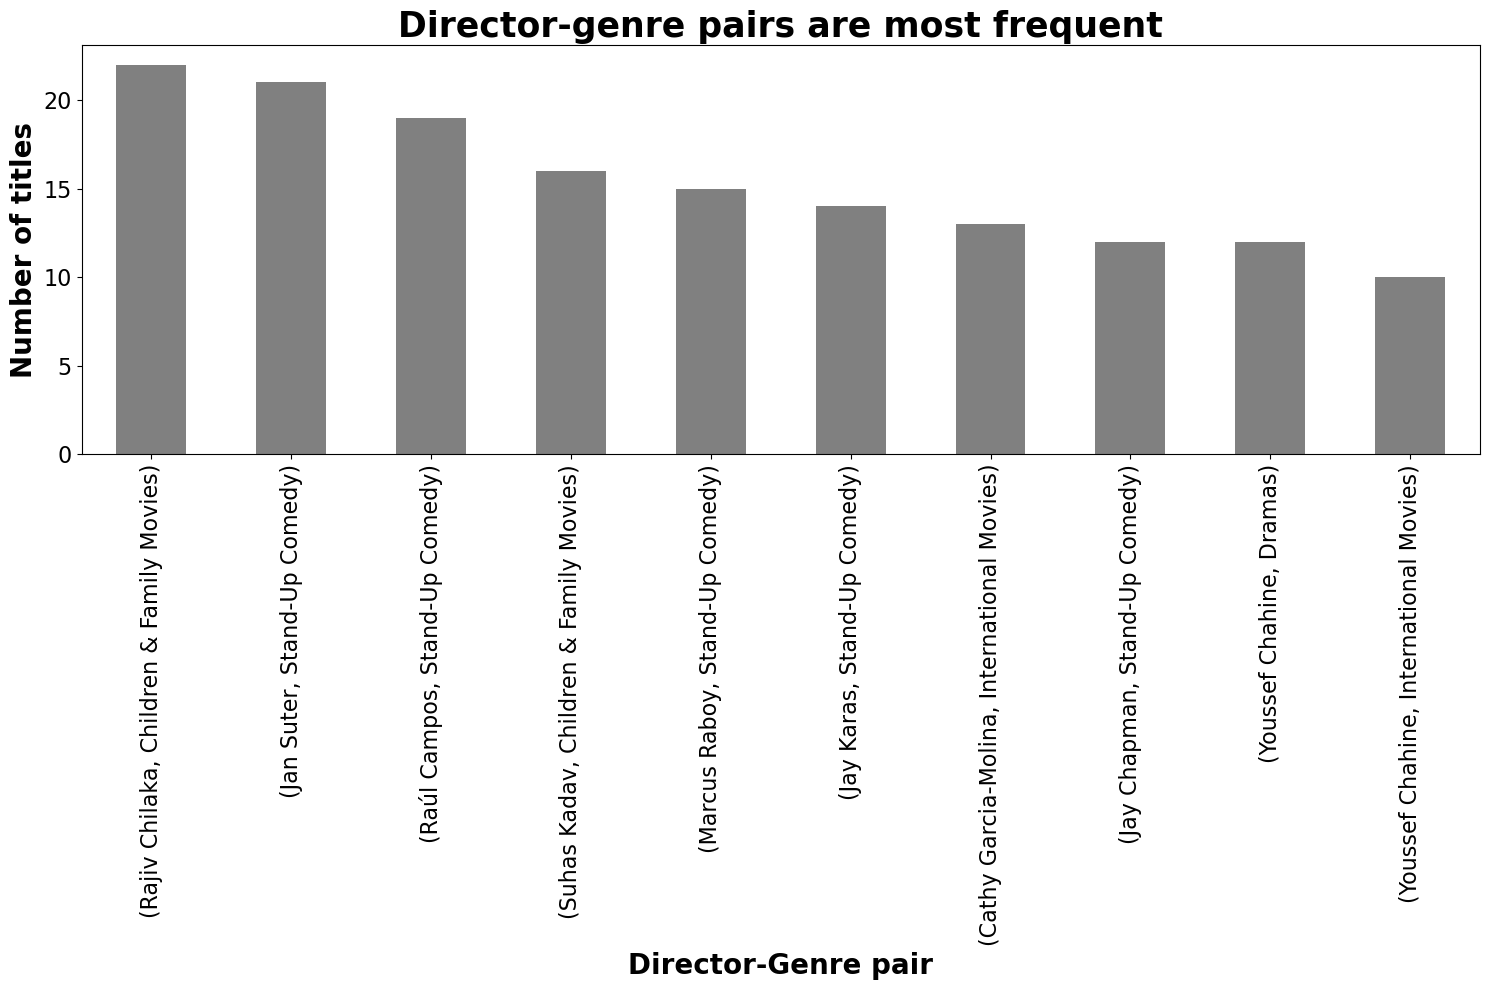

In [6]:
df = df.dropna(subset=['director'])

df['director'] = df['director'].str.split(', ')
df['listed_in'] = df['listed_in'].str.split(', ')

df = df.explode('director')
df = df.explode('listed_in')

df['director'] = df['director'].str.strip()

pair_counts = df.groupby(['director', 'listed_in']).size().sort_values(ascending=False).head(10)

pair_counts.plot(kind='bar', figsize=(15,10), color='grey')

plt.xlabel('Director-Genre pair', fontweight='bold', fontsize=20)
plt.ylabel("Number of titles", fontweight='bold', fontsize=20)
plt.title("Director-genre pairs are most frequent", fontweight='bold', fontsize=25)

plt.xticks(rotation=90, fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()
plt.show()

<h4>Insights</h4>

- Certain director-genre combinations are frequent.
- Directors specialize in specific genres.
- Strong pattern of repeated genre preference.
- Popular genres have more collaborations.
- Pair frequency shows industry trends.

<h3>14.How many titles have unknown directors or cast members?</h3>

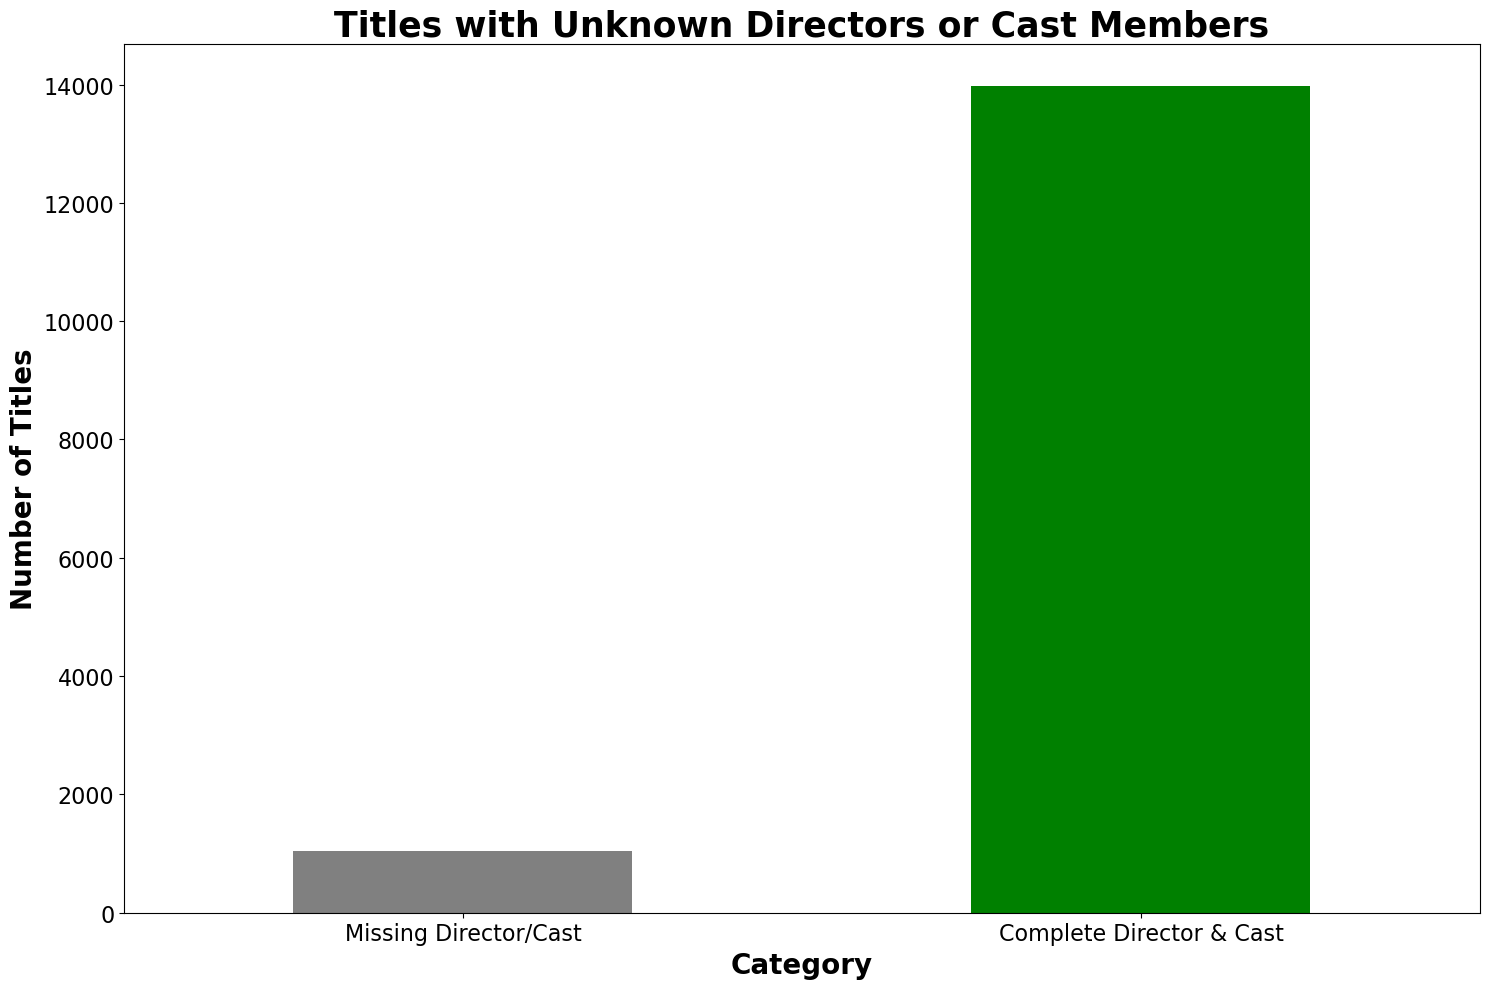

In [15]:
missing_titles = df[df[['director','cast']].isnull().any(axis=1)].shape[0]
complete_titles = df.shape[0] - missing_titles

counts = pd.Series([missing_titles, complete_titles],
                   index=['Missing Director/Cast', 'Complete Director & Cast'])

counts.plot(kind='bar', figsize=(15,10), color=['grey','green'])

plt.xlabel("Category", fontweight='bold', fontsize=20)
plt.ylabel("Number of Titles", fontweight='bold', fontsize=20)
plt.title("Titles with Unknown Directors or Cast Members", fontweight='bold', fontsize=25)

plt.xticks(rotation=0, fontsize=16)
plt.yticks(fontsize=16)

plt.tight_layout()
plt.show()

<h4>Insights</h4>

- Many titles have missing information.
- Data completeness is not perfect.
- Known data still dominates overall.
- Missing data may affect analysis.
- Data cleaning is important.

<h2>4. Duration & Engagement</h2>

<h3>15. What is the average duration of Movies on Netflix?</h3>

In [4]:
import pandas as pd

df = pd.read_csv("netflix.csv")

movies = df[df['type'] == 'Movie'].copy()

movies['duration'] = movies['duration'].str.extract('(\d+)').astype(float)

avg_movie_duration = movies['duration'].mean()

print("Average Movie Duration:", avg_movie_duration)

Average Movie Duration: 99.57718668407311


<h4>Insights</h4>

- Average movie duration is around 100 minutes.
- Most movies fall within standard duration range.
- Extremely long/short movies are rare.
- Duration is consistent across dataset.
- Netflix follows industry standards.

<h3>16. What’s the most common number of seasons for TV shows?</h3>

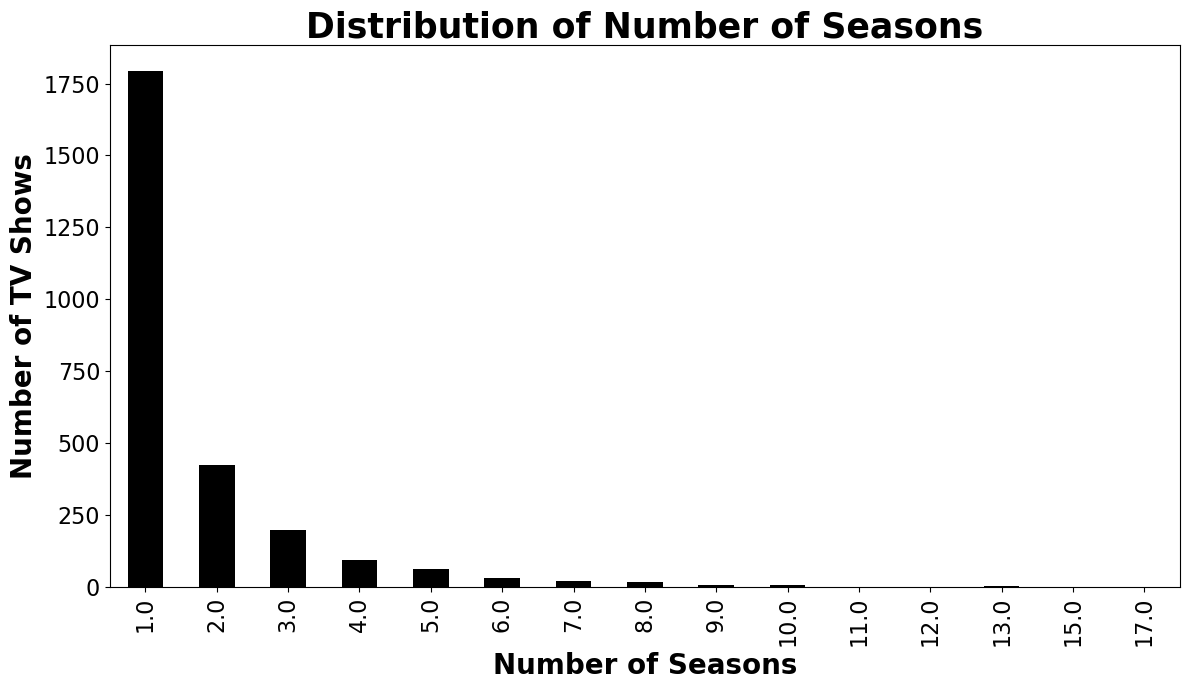

In [7]:
tv_shows = df[df['type'] == 'TV Show'].copy()

tv_shows['seasons'] = tv_shows['duration'].str.extract('(\d+)').astype(float)

season_counts = tv_shows['seasons'].value_counts().sort_index()

most_common = tv_shows['seasons'].mode()[0]

season_counts.plot(kind='bar', figsize=(12,7), color='k')

plt.xlabel("Number of Seasons", fontweight='bold', fontsize=20)
plt.ylabel("Number of TV Shows", fontweight='bold', fontsize=20)
plt.title("Distribution of Number of Seasons", fontweight='bold', fontsize=25)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()

<h4>Insights</h4>

- 1-season shows are most common.
- Limited series dominate Netflix.
- Multi-season shows are fewer.
- Short-format content is preferred.
- Long-running series are less frequent.

<h3>17. Is there a trend in movie durations over the years?</h3>

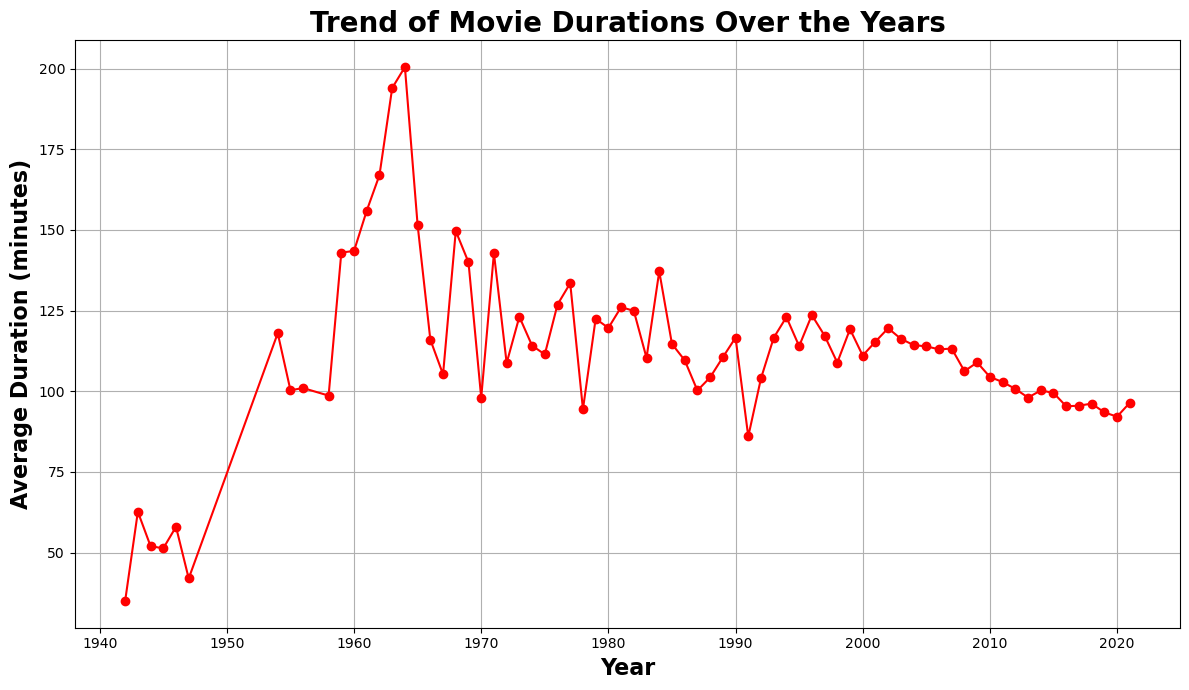

In [10]:
movies = df[df['type'] == 'Movie'].copy()

movies['duration'] = movies['duration'].str.extract('(\d+)').astype(float)

movies = movies.dropna(subset=['release_year', 'duration'])

avg_duration_year = movies.groupby('release_year')['duration'].mean()

avg_duration_year = avg_duration_year.sort_index()

avg_duration_year.plot(kind='line', figsize=(12,7), marker='o', color='r')

plt.xlabel("Year", fontweight='bold', fontsize=16)
plt.ylabel("Average Duration (minutes)", fontweight='bold', fontsize=16)
plt.title("Trend of Movie Durations Over the Years", fontweight='bold', fontsize=20)

plt.grid()
plt.tight_layout()
plt.show()

<h4>Insights</h4>

- Movie duration is relatively stable over years.
- No major increase or decrease trend.
- Minor fluctuations exist.
- Standard duration maintained over time.
- Industry norms remain consistent.

<h3>18.In which months does Netflix add the most content?</h3>

Month with most content: July


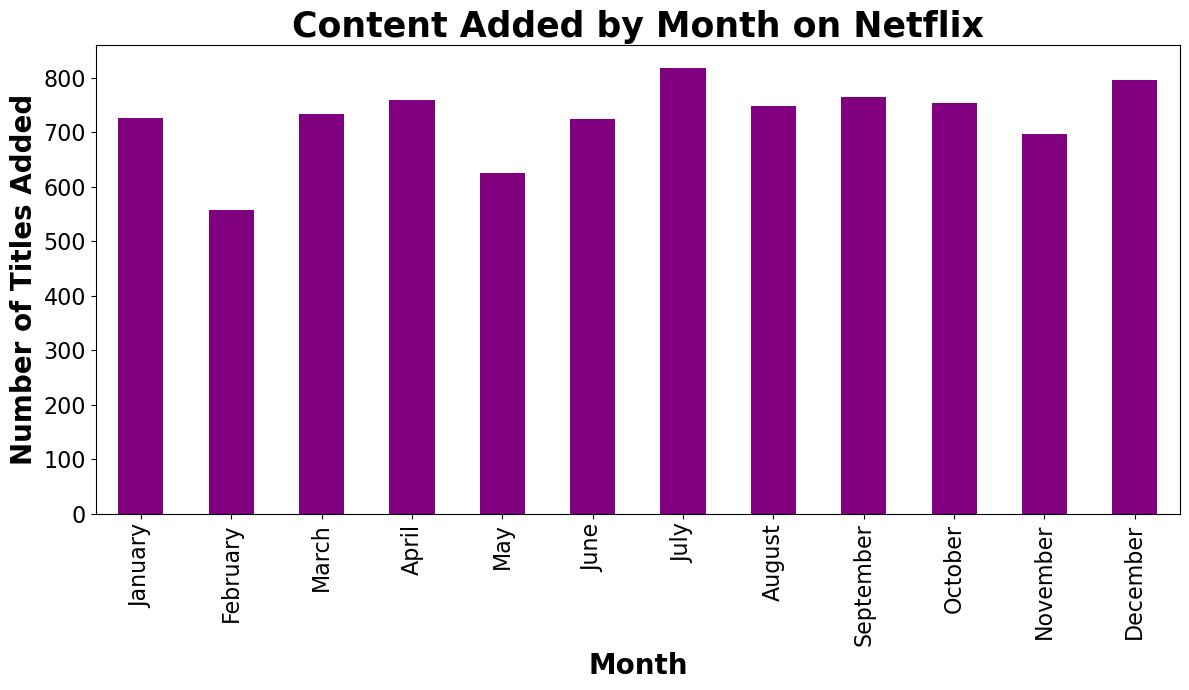

In [4]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

df = df.dropna(subset=['date_added'])

df['month'] = df['date_added'].dt.month_name()

month_counts = df['month'].value_counts()

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

month_counts = month_counts.reindex(month_order)

print("Month with most content:", month_counts.idxmax())

month_counts.plot(kind='bar', figsize=(12,7), color='purple')

plt.xlabel("Month", fontweight='bold', fontsize=20)
plt.ylabel("Number of Titles Added", fontweight='bold', fontsize=20)
plt.title("Content Added by Month on Netflix", fontweight='bold', fontsize=25)

plt.xticks(rotation=90, fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()

<h4>Insights</h4>

- July has highest content addition.
- Mid-year sees peak releases.
- Early months have lower additions.
- Seasonal trend is visible.
- Content release is not uniform across months.

<h3>19. How does the genre distribution vary across different years?</h3>

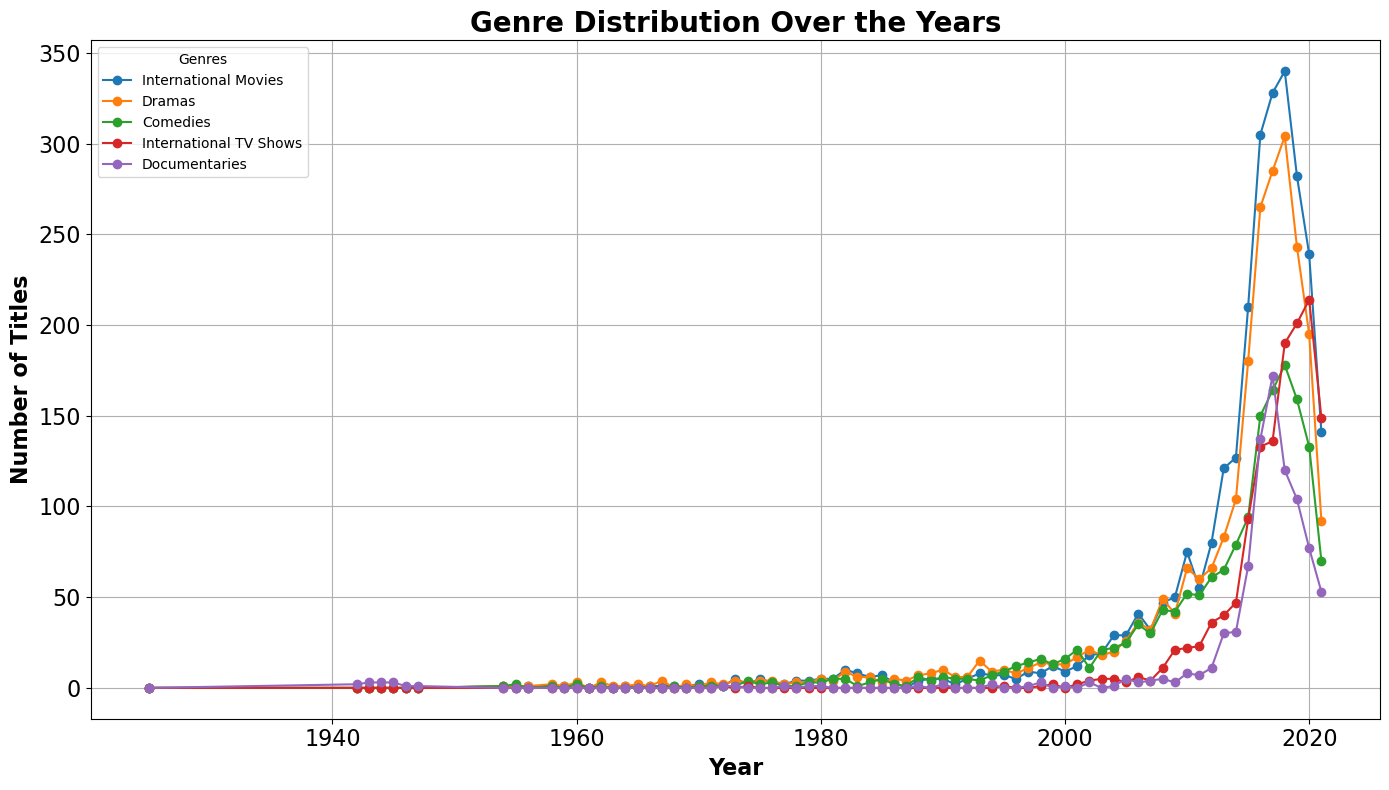

In [5]:
df = df.dropna(subset=['listed_in', 'release_year'])

df['listed_in'] = df['listed_in'].str.split(', ')
df = df.explode('listed_in')

genre_year = df.groupby(['release_year', 'listed_in']).size().unstack(fill_value=0)

top_genres = df['listed_in'].value_counts().head(5).index

genre_year = genre_year[top_genres]

genre_year.plot(kind='line', figsize=(14,8), marker='o')

plt.xlabel("Year", fontweight='bold', fontsize=16)
plt.ylabel("Number of Titles", fontweight='bold', fontsize=16)
plt.title("Genre Distribution Over the Years", fontweight='bold', fontsize=20)

plt.xticks(fontsize=16)
plt.yticks(fontsize=16)
plt.legend(title="Genres")
plt.grid()
plt.tight_layout()
plt.show()

<h4>Insights</h4>

- Some genres grow over time.
- Others decline or remain stable.
- Trends vary across genres.
- Audience preference changes yearly.
- Top genres remain consistent overall.

<h3>20. Which countries produce the most content in each genre?</h3>

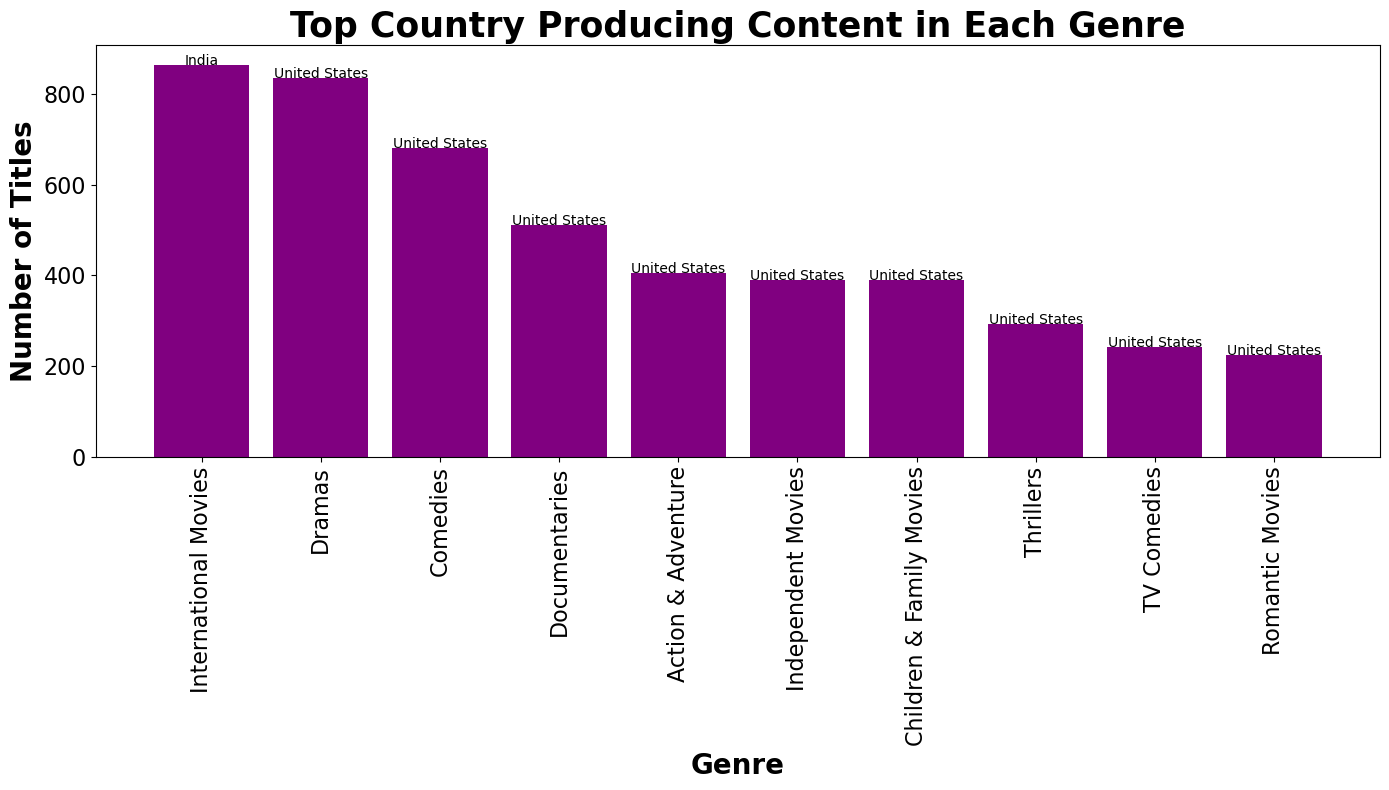

In [17]:
df = df.dropna(subset=['country', 'listed_in'])

df['country'] = df['country'].str.split(', ')
df['listed_in'] = df['listed_in'].str.split(', ')

df = df.explode('country')
df = df.explode('listed_in')

genre_country = df.groupby(['listed_in', 'country']).size()

top_country_per_genre = genre_country.groupby(level=0).idxmax()
top_counts = genre_country.groupby(level=0).max()

result = pd.DataFrame({
    'Genre': [i[0] for i in top_country_per_genre],
    'Country': [i[1] for i in top_country_per_genre],
    'Count': top_counts.values
})

result = result.sort_values('Count', ascending=False).head(10)

plt.figure(figsize=(14,8))

plt.bar(result['Genre'], result['Count'], color='purple')

for i, country in enumerate(result['Country']):
    plt.text(i, result['Count'].iloc[i], country, ha='center', fontsize=10)

plt.xlabel("Genre", fontweight='bold', fontsize=20)
plt.ylabel("Number of Titles", fontweight='bold', fontsize=20)
plt.title("Top Country Producing Content in Each Genre", fontweight='bold', fontsize=25)

plt.xticks(rotation=90, fontsize=16)
plt.yticks(fontsize=16)
plt.tight_layout()
plt.show()

<h4>Insights</h4>

- India has produced most content in a single type of genre.
- Certain countries dominate specific genres.
- USA leads in most genres.
- India dominates international content.
- Genre production varies by country.
- Global diversity exists but uneven.